In [4]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import platform

if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('NumPy 버전:', np.__version__)
print('환경 설정 완료')

NumPy 버전: 2.3.5
환경 설정 완료


In [5]:
# 데이터 로드
df1 = pd.read_csv('data/서울특별시 공공자전거 일별 대여건수_25.7-12.csv')
df1.head()

,대여일자,대여건수
0,2025-07-01,132914
1,2025-07-02,151653
2,2025-07-03,151092
3,2025-07-04,151367
4,2025-07-05,118354


In [8]:
# 데이터 로드
df2 = pd.read_excel('data/대여소별 대여내역(2017년).xlsx')
df2.head()

,대여소 그룹,대여소 명,대여 일자 / 월,대여 건수
0,그룹명 없음,대여소명 없음,2017-01-01,0
1,광진구,500. 어린이대공원역 3번출구 앞,2017-01-01,20
2,광진구,501. 광진구의회 앞,2017-01-01,10
3,광진구,502. 뚝섬유원지역 1번출구 앞,2017-01-01,9
4,광진구,503. 더샵스타시티 C동 앞,2017-01-01,9


In [9]:
# df1의 일자별 대여건수 top10
df1.shape
df1['대여일자'].value_counts()
df1['대여일자'].dtypes

dtype('O')

In [10]:
# '대여일자' 데이터 타입 변환, to_datetime()
df1['대여일자'] = pd.to_datetime(df1['대여일자'])
df1.dtypes
df1['Year'] = df1['대여일자'].dt.year
df1['Month'] = df1['대여일자'].dt.month
df1['Day'] = df1['대여일자'].dt.day
df1['Month'].value_counts()

Month
7     31
8     31
10    31
12    31
9     30
11    30
Name: count, dtype: int64

In [11]:
# df1의 2025년도 월별 대여건수 
df1_rentals = df1.groupby('Month')['Month'].sum()
df1_rentals
df1_rentals.index
#df1_rentals.values

Index([7, 8, 9, 10, 11, 12], dtype='int32', name='Month')

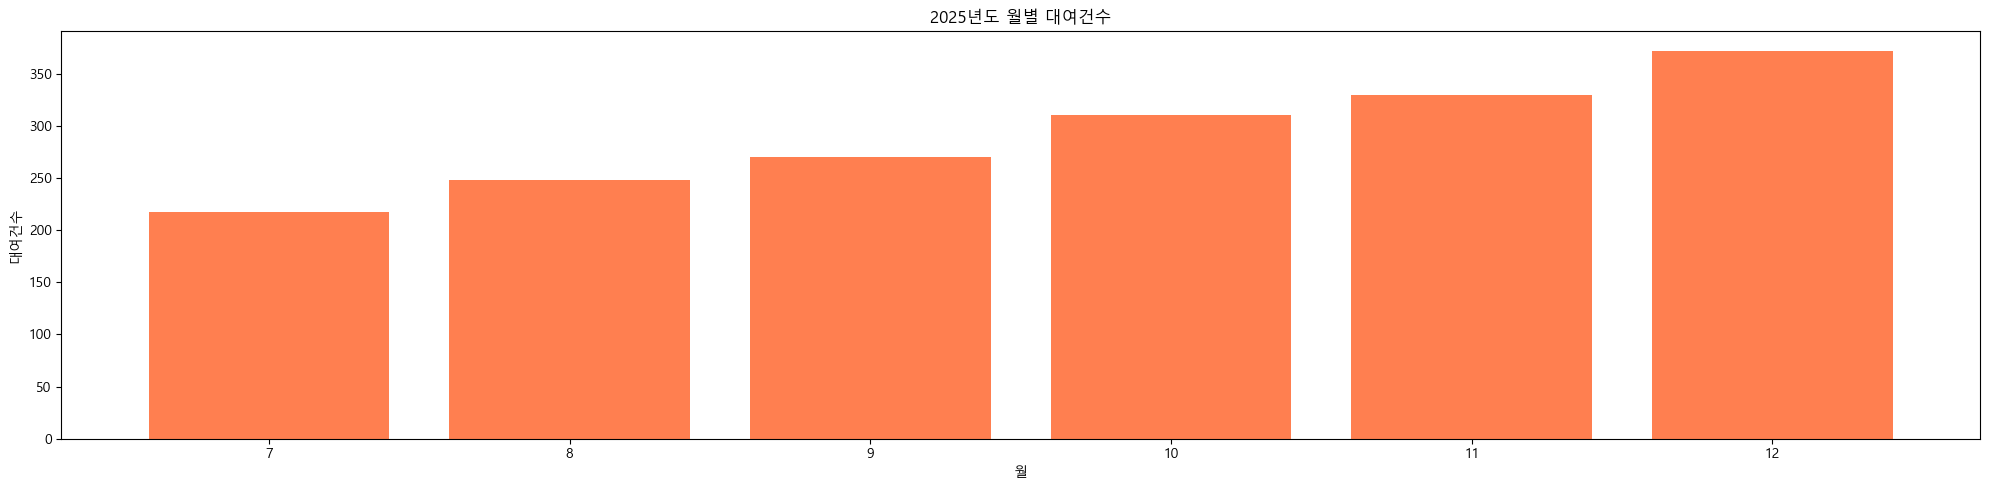

In [12]:
# 막대 그래프
plt.figure(figsize=(20, 5))
plt.bar(df1_rentals.index, df1_rentals.values, color='coral')
plt.title('2025년도 월별 대여건수')
plt.xlabel('월')
plt.ylabel('대여건수')
# plt.gca().invert_xaxis()
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
# 0: 월요일, 1. 화요일...
# 'weekday' 컬럼을 생성하고 요일 정보를 저장
df1['weekday'] = df1['대여일자'].dt.weekday
df1

,대여일자,대여건수,Year,Month,Day,weekday
0,2025-07-01,132914,2025,7,1,1
1,2025-07-02,151653,2025,7,2,2
2,2025-07-03,151092,2025,7,3,3
3,2025-07-04,151367,2025,7,4,4
4,2025-07-05,118354,2025,7,5,5
...,...,...,...,...,...,...
179,2025-12-27,42381,2025,12,27,5
180,2025-12-28,40774,2025,12,28,6
181,2025-12-29,66652,2025,12,29,0
182,2025-12-30,71026,2025,12,30,1


In [23]:
# 요일을 매핑하는 딕셔너리 객체 생성
week_dict = {
    0 : '월',
    1 : '화',
    2 : '수',
    3 : '목',
    4 : '금',
    5 : '토',
    6 : '일'
}

df1['weekday'] = df1['대여일자'].dt.weekday.map(week_dict)
df1

,대여일자,대여건수,Year,Month,Day,weekday
0,2025-07-01,132914,2025,7,1,화
1,2025-07-02,151653,2025,7,2,수
2,2025-07-03,151092,2025,7,3,목
3,2025-07-04,151367,2025,7,4,금
4,2025-07-05,118354,2025,7,5,토
...,...,...,...,...,...,...
179,2025-12-27,42381,2025,12,27,토
180,2025-12-28,40774,2025,12,28,일
181,2025-12-29,66652,2025,12,29,월
182,2025-12-30,71026,2025,12,30,화


In [43]:
# 요일별 대여건수 그래프 생성
order = ['월', '화', '수', '목', '금', '토', '일']
df1['weekday'].value_counts()
result = df1.groupby('weekday')['대여건수'].sum().reindex(order)
result

weekday
월    2860997
화    3125484
수    3052445
목    3120020
금    2871785
토    2322797
일    2294234
Name: 대여건수, dtype: int64

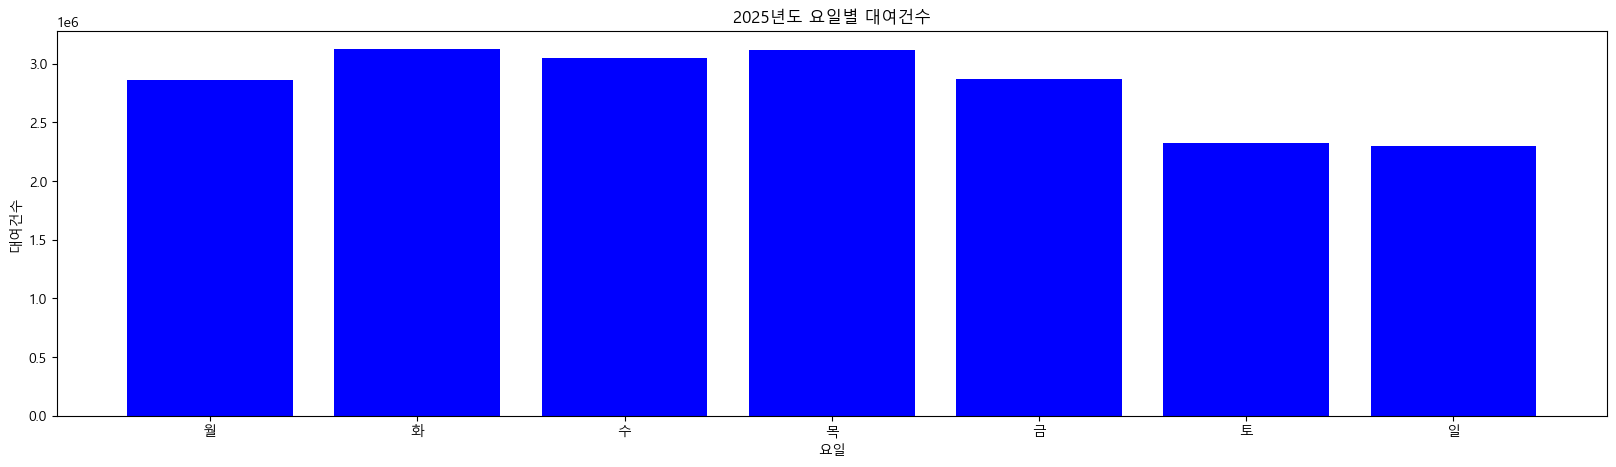

In [44]:
# 막대 그래프
plt.figure(figsize=(20, 5))
plt.bar(result.index, result.values, color='blue')
plt.title('2025년도 요일별 대여건수')
plt.xlabel('요일')
plt.ylabel('대여건수')
# plt.gca().invert_xaxis()
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
plt.show()

In [47]:
df2.shape
df2.info()
df2.head()
#df2['대여소 명'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245446 entries, 0 to 245445
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   대여소 그룹     245446 non-null  object        
 1   대여소 명      245446 non-null  object        
 2   대여 일자 / 월  245446 non-null  datetime64[ns]
 3   대여 건수      245446 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 7.5+ MB


,대여소 그룹,대여소 명,대여 일자 / 월,대여 건수
0,그룹명 없음,대여소명 없음,2017-01-01,0
1,광진구,500. 어린이대공원역 3번출구 앞,2017-01-01,20
2,광진구,501. 광진구의회 앞,2017-01-01,10
3,광진구,502. 뚝섬유원지역 1번출구 앞,2017-01-01,9
4,광진구,503. 더샵스타시티 C동 앞,2017-01-01,9


In [ ]:
# df2 컬럼명 수정
df2.head()
df2.rename(columns={'대여소 그룹': '그룹'})
df2.columns =['그룹', '대여소', '일자', '건수']
df2

In [57]:
# 대여소별 대여건수 Top 5
df2['대여소'].value_counts()
station_top10 = df2.groupby('대여소')['건수'].sum().sort_values(ascending = False).head(10)

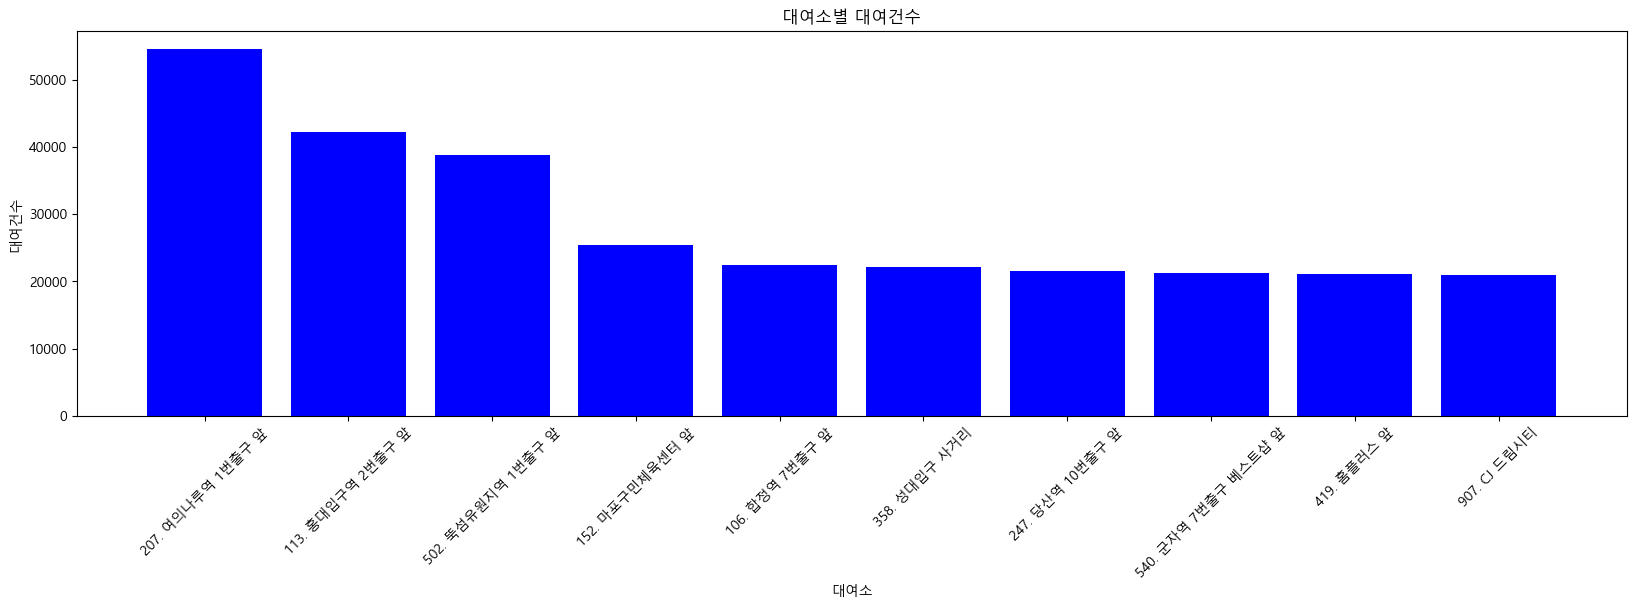

In [58]:
plt.figure(figsize=(20, 5))
plt.bar(station_top10.index, station_top10.values, color='blue')
plt.title('대여소별 대여건수')
plt.xlabel('대여소')
plt.ylabel('대여건수')
# plt.gca().invert_xaxis()
plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()

- 그룹별 총 대여건수 Top10

In [62]:
df2.head()
gu_top10 = df2.groupby('그룹')['건수'].sum().sort_values(ascending=False).head(10)
gu_top10

그룹
마포구     781594
영등포구    653789
종로구     487342
성동구     377067
서대문구    310396
광진구     306407
동대문구    241653
중구      240668
은평구     184674
송파구     160528
Name: 건수, dtype: int64

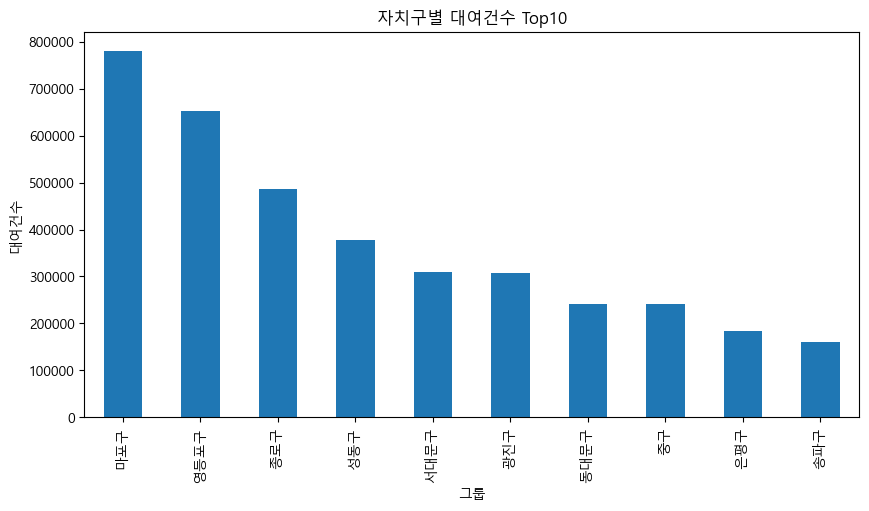

In [64]:
gu_top10.plot(
    kind='bar',
    figsize=(10, 5)
)
plt.title('자치구별 대여건수 Top10')
plt.ylabel('대여건수')
plt.show()

 - 월별 총 대여건수 Top10

In [70]:
df2.head()
df2.dtypes
df2['월'] = df2['일자'].dt.month
month_rent = df2.groupby('월')['건수'].sum()
month_rent

월
1      84149
2      85752
3     188767
4     319181
5     451223
6     536705
7     388664
8     540559
9     889873
10    863104
11    482618
12    200436
Name: 건수, dtype: int64

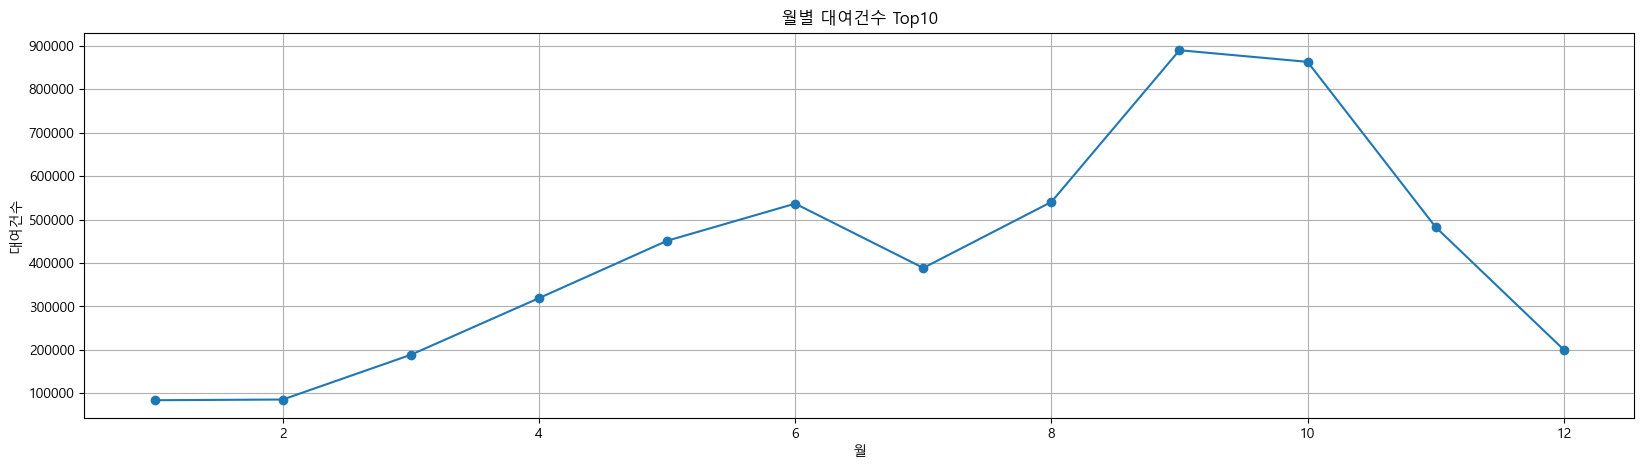

In [75]:
month_rent.plot(
    kind='line',
    marker= 'o',
    figsize=(20, 5)
)
plt.title('월별 대여건수 Top10')
plt.ylabel('대여건수')
plt.grid()
plt.show()

- 대여소별 평균 대여건수 Top15

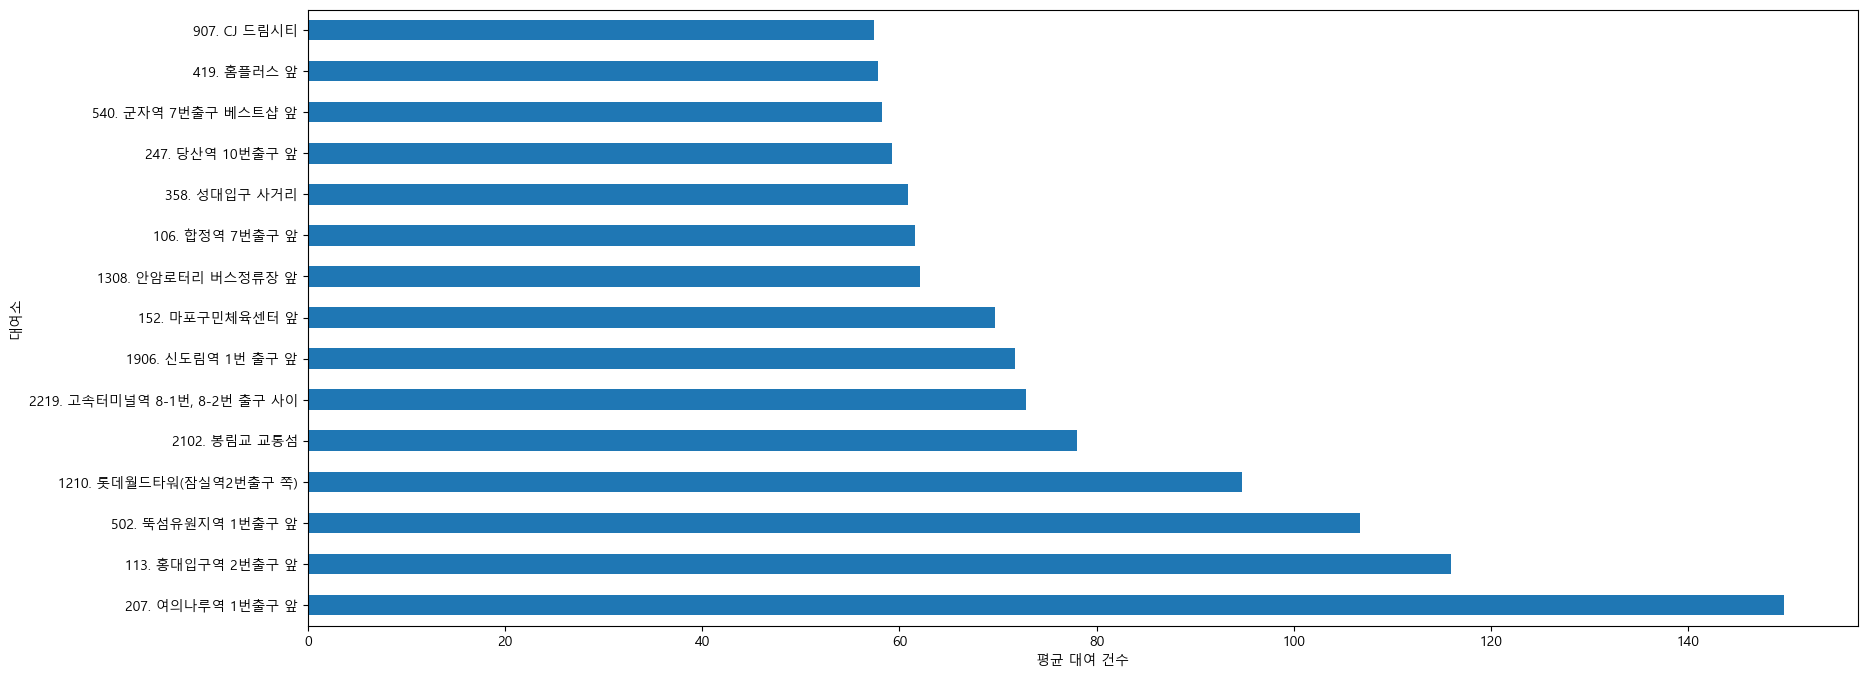

In [86]:
#df2.info()
group_mean = df2.groupby('대여소')['건수'].mean().sort_values(ascending=False).head(15)
group_mean

# 그래프
group_mean.plot(
    kind='barh',
    figsize=(20, 8)
)
plt.xlabel('평균 대여 건수')
plt.show()